# QC and Integration of samples
#### This notebook goes through the quality control of xenium samples. <br>I then perform basic clustering and colour the resulting graph by sample to assess the extent to which batch correction is required<br> This then informs my choice of integration technique 
##### Final Choice for Cross-Section Samples = Pending
##### Final Choice for EnFace samples = Pending

# 1) Loading Data, setting up zarr arrays of xenium experiments

In [1]:
import spatialdata as sd
from spatialdata_io import xenium


import matplotlib.pyplot as plt
import seaborn as sns

import scanpy as sc
#import squidpy as sq only needed for spatial visualisation

d:\Dom\Virtual_Environments\napari_registration_project\.venv\Lib\site-packages\dask\dataframe\__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
d:\Dom\Virtual_Environments\napari_registration_project\.venv\Lib\site-packages\xarray_schema\__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
d:\Dom\Virtual_Environments\napari_registration_project\.venv\Lib\site-packages\spatialdata\_core\query\relational_query.py:530: FutureWarning: functools.partial will be a method descriptor in fu

In [6]:
#debug script - removing cell artefacts from import segmentation algorithm
import pandas as pd
from pathlib import Path 

xeniums_folders = Path("D:/Dom/Psoriasis project/4th year data/Second Round Data/Xenium outputs - second round/Resegmented Xenium Outputs/")
for dir in ['D3IMQ', 'D7IMQ', 'D10IMQ', 'EF1_Ctrl', 'EF2_Ctrl', 'EF2_D10']:
    boundaries_file = xeniums_folders / (dir + '_reseg')/'Outs' /"nucleus_boundaries.parquet" #change from cells to nucleus 
    df = pd.read_parquet(boundaries_file)
    print(f'{dir} shape is {df.shape}')

    vertex_counts = df.groupby('cell_id').size()
    valid_cells = vertex_counts[vertex_counts >=4].index #remove any cells that have fewer than 4 vertices, they cause an error with the spatialdata reader
    df_clean = df[df['cell_id'].isin(valid_cells)]
    print(f'cleaned shape is {df_clean.shape}, removed : {df.shape[0]-df_clean.shape[0]}')

    df_clean.to_parquet(boundaries_file)

D3IMQ shape is (1716986, 4)
cleaned shape is (1716981, 4), removed : 5
D7IMQ shape is (2371983, 4)
cleaned shape is (2371983, 4), removed : 0
D10IMQ shape is (2204029, 4)
cleaned shape is (2204029, 4), removed : 0
EF1_Ctrl shape is (1616451, 4)
cleaned shape is (1616435, 4), removed : 16
EF2_Ctrl shape is (472031, 4)
cleaned shape is (472028, 4), removed : 3
EF2_D10 shape is (666784, 4)
cleaned shape is (666784, 4), removed : 0


In [8]:
#Run one time only
from pathlib import Path

xeniums_folder = Path("D:/Dom/Psoriasis project/4th year data/Second Round Data/Xenium outputs - second round/Resegmented Xenium Outputs/")
runs = {}

for dir in ['D3IMQ']: #, 'D3IMQ', 'D7IMQ', 'D10IMQ' need to be done as well, leave out for now to avoid memory errors
        xenium_path = xeniums_folder / (dir + '_reseg') / 'outs'
        runs[dir] = xenium(xenium_path,
                cells_boundaries = False,
                cells_table = True,
                nucleus_labels = True,
                cells_labels = True,
                nucleus_boundaries = False            
                ) 

        zarr_path = "D:/Xenium_2_sdata_zarrs" /dir + ".zarr"
        runs[dir].write(zarr_path)


C:\Users\dbuxton\AppData\Local\Temp\ipykernel_17988\2719810108.py:9: DeprecationWarning: The default value of `cells_as_circles` will change to `False` in the next release. Please pass `True` explicitly to maintain the current behavior.
  runs[dir] = xenium(xenium_path,
C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.13_3.13.3568.0_x64__qbz5n2kfra8p0\Lib\functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


MemoryError: Unable to allocate 4.55 GiB for an array with shape (23878, 51109) and data type uint32

In [2]:
#Load zarr stores of spatialdata objects

from pathlib import Path
xeniums_folder = Path("D:/Dom/Xenium_2_sdata_zarrs")
runs = {}
samples_list = ['Ctrl'] #list of zarr names, e.g. , 'D3IMQ', 'D7IMQ', 'D10IMQ'

for dir in samples_list: 
    zarr_path = xeniums_folder / (dir + "_sdata.zarr")
    runs[dir] = sd.read_zarr(zarr_path)

for sdata in runs.values():
    print(sdata)

SpatialData object, with associated Zarr store: D:\Dom\Xenium_2_sdata_zarrs\Ctrl_sdata.zarr
├── Images
│     └── 'morphology_focus': DataTree[cyx] (4, 13706, 51100), (4, 6853, 25550), (4, 3426, 12775), (4, 1713, 6387), (4, 856, 3193)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (13706, 51100), (6853, 25550), (3426, 12775), (1713, 6387), (856, 3193)
│     └── 'nucleus_labels': DataTree[yx] (13706, 51100), (6853, 25550), (3426, 12775), (1713, 6387), (856, 3193)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 13) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (36693, 1) (2D shapes)
│     ├── 'cell_circles': GeoDataFrame shape: (36702, 2) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (34471, 1) (2D shapes)
└── Tables
      └── 'table': AnnData (36702, 5056)
with coordinate systems:
    ▸ 'global', with elements:
        morphology_focus (Images), cell_labels (Labels), nucleus_labels (Labels), transcripts (Points), cell_bo

In [5]:
#Add in compartment segmentation to the spatialdata objects
import geopandas as gp
import numpy as np
from pathlib import Path
from spatialdata.models import ShapesModel

def add_compartment_segmentations(sdata, compartment_segmentation_folder):
    """
    add a collection of tissue segmentations to the an sdata object. Updates the sdata object and the anndata object contained within.
    inputs:
        -sdata = sdata object
        -Compartment_segmentation_folders = path to folder with segmentation.geojson files
    """
    
    compartment_paths = {}
    compartment_segmentation_folder = Path(compartment_segmentation_folder)
    for file in compartment_segmentation_folder.glob("*.geojson"):
        compartment_paths[file.stem] = str(file)

    for compartment, path in compartment_paths.items():
        geojson = gp.read_file(path)
        shape = geojson.geometry.union_all()
        gdf = gp.GeoDataFrame(geometry=[shape])
        sdata.shapes[compartment] = ShapesModel.parse(gdf)

    adata = sdata.tables['table']
    obs = adata.obs
    spatial_coords = adata.obsm['spatial']

    pixel_size = 0.2125  # microns per pixel (Xenium standard)

    xenium_shapes = {'cell_boundaries', 'cell_circles', 'nucleus_boundaries'}
    compartment_shapes = {k: v for k, v in sdata.shapes.items() if k not in xenium_shapes}

    cell_points = gp.GeoDataFrame(
        obs,
        geometry=gp.points_from_xy(
            spatial_coords[:, 0] / pixel_size,
            spatial_coords[:, 1] / pixel_size
        ),
        index=obs.index
    )

    compartment_gdf = gp.GeoDataFrame(
        {'compartment': list(compartment_shapes.keys())},
        geometry=[v.geometry.iloc[0] for v in compartment_shapes.values()]
    )

    if 'compartment' in adata.obs.columns:
        adata.obs.drop(columns='compartment', inplace=True)
    joined = gp.sjoin(cell_points, compartment_gdf, how='left', predicate='within')
    # Drop duplicate cells, keeping first match
    joined = joined[~joined.index.duplicated(keep='first')]

    adata.obs['compartment'] = joined['compartment'].fillna('out_of_bounds').values

#dictionary containing condition names and compartment_segmentation folder paths (contains your geojson segmentations)
segs = {'Ctrl': r"D:\Dom\Psoriasis project\4th year data\Second Round Data\Xenium outputs - second round\output-XETG00160__0093234__ctrl__20260211__140710\Compartment segmentations"}

for condition, sdata in runs.items():
    add_compartment_segmentations(sdata, segs[condition])
    print('added shapes and labelled cells. Unique compartments below')
    print(sdata.tables['table'].obs['compartment'].unique())



added shapes and labelled cells. Unique compartments below
['out_of_bounds' 'Ventral_epidermis_F1' 'Ventral_dermis_F1' 'Cartilage_F1'
 'Dorsal_dermis_F1' 'Dorsal_epidermis_F1' 'Dorsal_epidermis_F2'
 'Dorsal_dermis_F2' 'Cartilage_F2' 'Ventral_dermis_F2'
 'Ventral_epidermis_F2' 'Ventral_epidermis_F3' 'Ventral_dermis_F3'
 'Cartilage_F3' 'Dorsal_dermis_F3' 'Dorsal_epidermis_F3'
 'Dorsal_epidermis_M1' 'Dorsal_dermis_M1' 'Cartilage_M1'
 'Ventral_dermis_M1' 'Ventral_epidermis_M1' 'Dorsal_epidermis_M2'
 'Dorsal_dermis_M2' 'Cartilage_M2' 'Ventral_dermis_M2'
 'Ventral_epidermis_M2' 'Ventral_epidermis_M3' 'Ventral_dermis_M3'
 'Dorsal_epidermis_M3' 'Cartilage_M3' 'Dorsal_dermis_M3']


In [26]:
from collections import defaultdict
keys_to_skip = {'cell_boundaries', 'cell_circles', 'nucleus_boundaries'}


replicate_sds = {} #dictionary of replicate spatialdata objects and their names
for condition, sdata in runs.items():

    shapes_by_replicate = defaultdict(list)

    #group shape names by replicate
    for shape_name in sdata.shapes.keys():
            if shape_name in keys_to_skip:
                continue
            if "_" not in shape_name:
                    continue
            replicate = shape_name.rsplit("_", 1)[1]
            shapes_by_replicate[replicate].append(shape_name)

    for replicate, shape_names in shapes_by_replicate.items():
            geometries = []

            for shape_name in shape_names:
                gdf = sdata.shapes[shape_name]
                geometries.extend(gdf.geometry)

            #merge all compartment polygons
            tissue_polygon = gp.GeoSeries(geometries).union_all()
            
            name = f'{condition}_{replicate}'

            replicate_sds[name] = sd.polygon_query(
                  sdata,
                  polygon = tissue_polygon,
                  target_coordinate_system = 'global'
            )

In [33]:
#following the dividing up of large spatialdata objects, you may want to delete the 'runs' dictionary to save memory
del runs

In [27]:
#extract anndata tables from spatial data objects
tables = {}

for condition, sdata in replicate_sds.items():
    tables[condition] = sdata.tables['table']

for condition, anndata in tables.items():
    print(tables[condition])

AnnData object with n_obs × n_vars = 6195 × 5056
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'cell_labels', 'compartment', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'spatialdata_attrs'
    obsm: 'spatial'
AnnData object with n_obs × n_vars = 6759 × 5056
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 't

# Calculate quality control metrics

In [28]:
#calculate QC metrics
for condition, adata in tables.items():
    sc.pp.calculate_qc_metrics(adata, inplace=True)

In [29]:
#calculate percentage of control probes and control codewords detected

for adata in tables.values():
    cprobes = (
        adata.obs["control_probe_counts"].sum() / adata.obs["total_counts"].sum() * 100
    )
    cwords = (
        adata.obs["control_codeword_counts"].sum() / adata.obs["total_counts"].sum() * 100
    )
    print(f"Negative DNA probe count % : {cprobes}")
    print(f"Negative decoding count % : {cwords}")

Negative DNA probe count % : 0.01593901593901594
Negative decoding count % : 0.0003465003465003465
Negative DNA probe count % : 0.026024780884577887
Negative decoding count % : 0.00044109798109454056
Negative DNA probe count % : 0.019382223916372163
Negative decoding count % : 0.0
Negative DNA probe count % : 0.009747029766732692
Negative decoding count % : 0.0
Negative DNA probe count % : 0.007225068096266807
Negative decoding count % : 0.0
Negative DNA probe count % : 0.005118536780952219
Negative decoding count % : 0.0008530894634920364


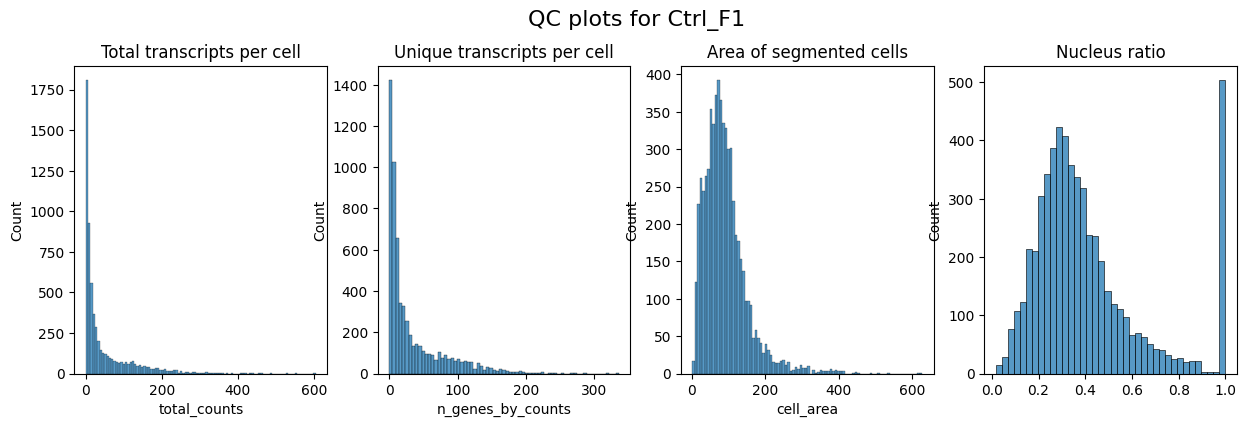

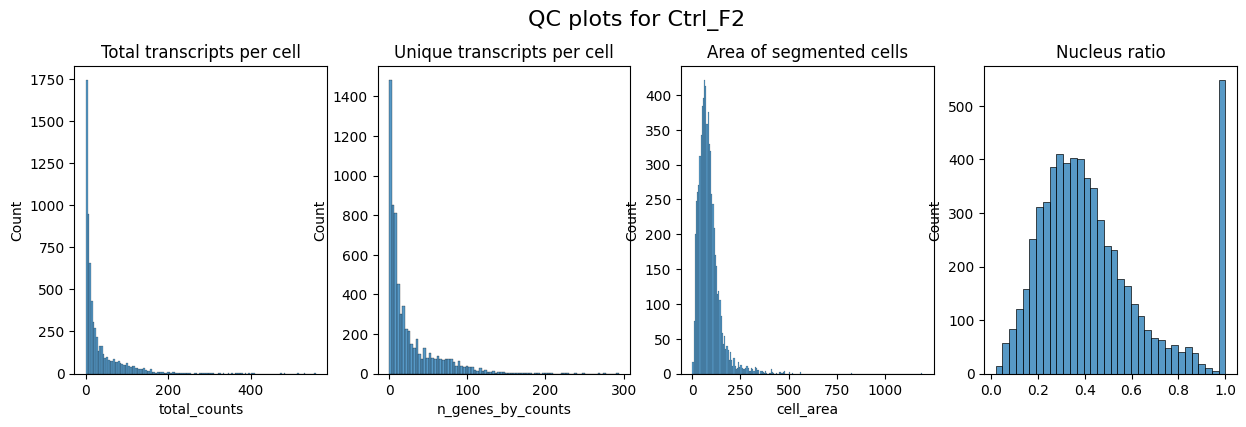

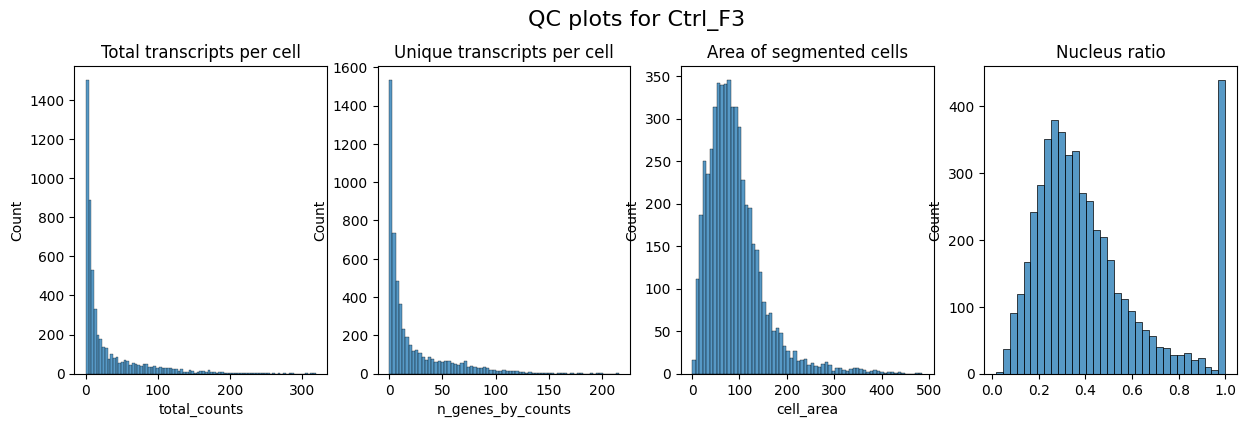

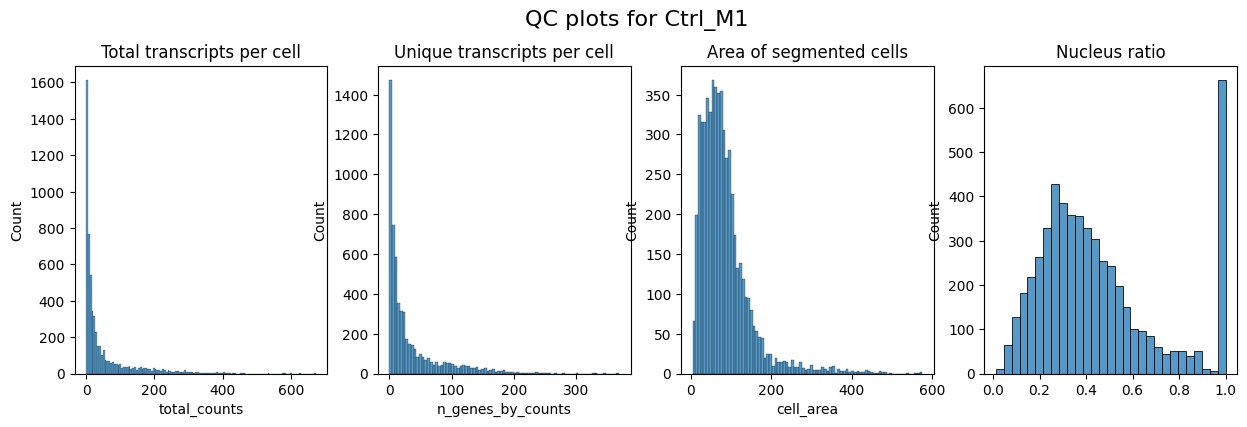

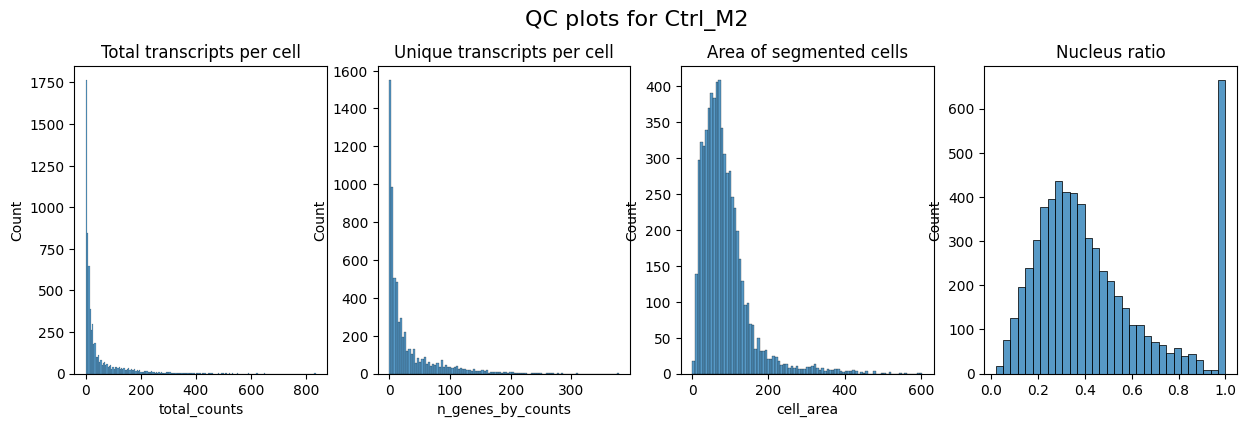

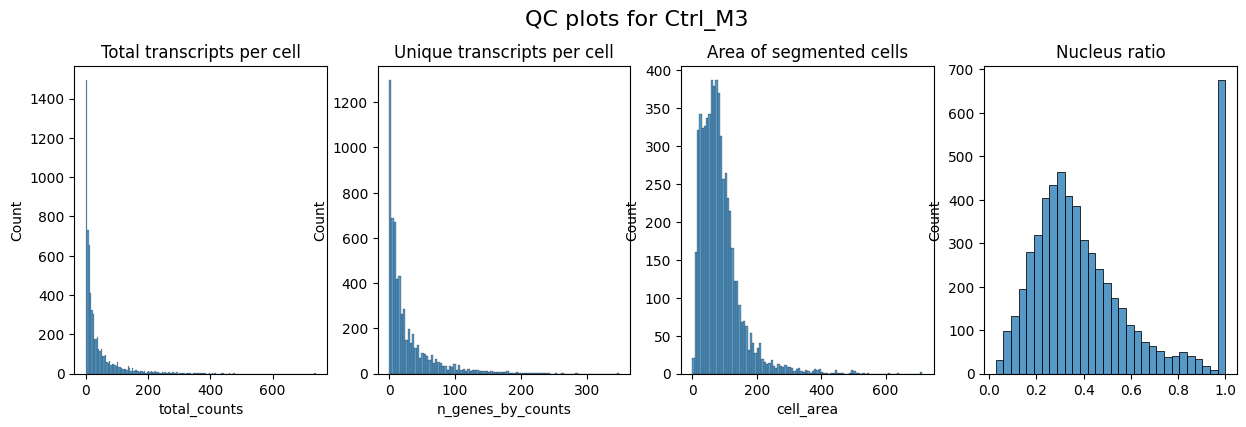

In [32]:
def qc_plots(name, adata):
    """
    name = name of adata object
    for a given adata object, generates 4 histograms: 
            1) Histogram of total_counts 
            2) n_genes_by_counts (unique transcripts detected per cell)
            3) Cell area
            4) Nucleus ratio
    """
    fig, axs = plt.subplots(1, 4, figsize=(15, 4))
    fig.suptitle(f"QC plots for {name}", fontsize=16, y = 1.02)

    axs[0].set_title("Total transcripts per cell")
    sns.histplot(
        adata.obs["total_counts"],
        kde=False,
        ax=axs[0],
    )

    axs[1].set_title("Unique transcripts per cell")
    sns.histplot(
        adata.obs["n_genes_by_counts"],
        kde=False,
        ax=axs[1],
    )


    axs[2].set_title("Area of segmented cells")
    sns.histplot(
        adata.obs["cell_area"],
        kde=False,
        ax=axs[2],
    )

    axs[3].set_title("Nucleus ratio")
    sns.histplot(
        adata.obs["nucleus_area"] / adata.obs["cell_area"],
        kde=False,
        ax=axs[3],
    )

for condition, adata in tables.items():
    qc_plots(condition, adata)

In [ ]:
#filter cells according to size
#Given we have chondrocytes in our sample, which are rather large, I will just filter out the smallest 1% quantile of cells. 

import numpy as np
from collections import defaultdict


def filter_cells(adata):
    #filter cells based on multiple metrics: size, low gene

    total_original_cells = len(adata) 
    total_original_cells_by_compartment = adata.obs['compartment'].value_counts().to_dict()

    #size based
    percentile_threshold = 1 #change this to filter out more or less cells
    size_threshold = np.percentile(adata.obs['cell_area'], percentile_threshold) 

    size_mask = adata.obs['cell_area'] > size_threshold 
    num_removed_size = (~size_mask).sum() #no. cells removed

    adata = adata[size_mask].copy()

    print(f'Removed {num_removed_size/total_original_cells *100:.2f}% of cells based on transcript/gene requirements')

    

    # #gene/transcript based
    before = len(adata)

    sc.pp.filter_cells(adata, min_counts = 10)
    sc.pp.filter_cells(adata, min_genes=10) #could change to 5 and see how this affects everything

    num_removed_genes = before - len(adata)

    print(f'Removed further {num_removed_genes/total_original_cells*100:.2f}% of cells based on transcript/gene requirements after size exclusion')
    
    
    # #negative control based - very stringent, but inspection of data shows low counts for each of these controls 
    control_mask = (
        (adata.obs['control_probe_counts'] == 0) &
        (adata.obs['genomic_control_counts'] == 0) &
        (adata.obs['control_codeword_counts'] == 0) &
        (adata.obs['unassigned_codeword_counts'] == 0)
    )   
    num_removed_controls = sum(~control_mask)

    adata = adata[control_mask].copy()

    print(f'Removed further {num_removed_controls/total_original_cells*100:.2f}% cells based on negative controls')
    print(f'Removed {len(adata)/total_original_cells *100:.2f}% of cells')

    #calculate % of cells removed by compartment
    total_final_cells_by_compartment = adata.obs['compartment'].value_counts().to_dict()
    
    original_by_type = defaultdict(int)
    final_by_type = defaultdict(int)

    for compartment, count in total_original_cells_by_compartment.items():
        comp_type = '_'.join(compartment.split('_')[:-1])
        original_by_type[comp_type] += count

    for compartment, count in total_final_cells_by_compartment.items():
        comp_type = '_'.join(compartment.split('_')[:-1])
        final_by_type[comp_type] += count

    for comp_type in sorted(original_by_type.keys()):
        original = original_by_type[comp_type]
        final = final_by_type.get(comp_type, 0)
        pct_removed = (1-final/original) *100
        pct_total = ((original-final)/total_original_cells)*100
        print(f'{comp_type}: {pct_removed:.2f}% cells removed, or {pct_total:.2f} of total OG cells')


    return adata

for condition, adata in tables.items():
    print(f'{"="*30}QC for {condition}{"="*30}')
    tables[condition] = filter_cells(adata)
    print(tables[condition])
    print("="*80)

Removed 1.00% of cells based on transcript/gene requirements
Removed further 38.72% of cells based on transcript/gene requirements after size exclusion
Removed further 1.95% cells based on negative controls
Removed 58.32% of cells
Cartilage: 90.10% cells removed, or 18.08 of total OG cells
Dorsal_dermis: 43.92% cells removed, or 10.49 of total OG cells
Dorsal_epidermis: 10.58% cells removed, or 2.05 of total OG cells
Ventral_dermis: 50.75% cells removed, or 7.05 of total OG cells
Ventral_epidermis: 17.40% cells removed, or 3.95 of total OG cells
out_of: 100.00% cells removed, or 0.05 of total OG cells
AnnData object with n_obs × n_vars = 3613 × 5056
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'cell_labels', 'compartment', 'n_genes_by_counts', 'log1p_

# Initial rough clustering
#### Colour by sample so we can see if we get sample specific clusters, assess the extent of the integration issue

In [ ]:
#Concatenate the anndata objects to perform clustering on them 
import anndata as ad


master_anndata = ad.concat(tables, index_unique='_')
master_anndata


AnnData object with n_obs × n_vars = 20127 × 5056
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'cell_labels', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_counts', 'n_genes'
    obsm: 'spatial'

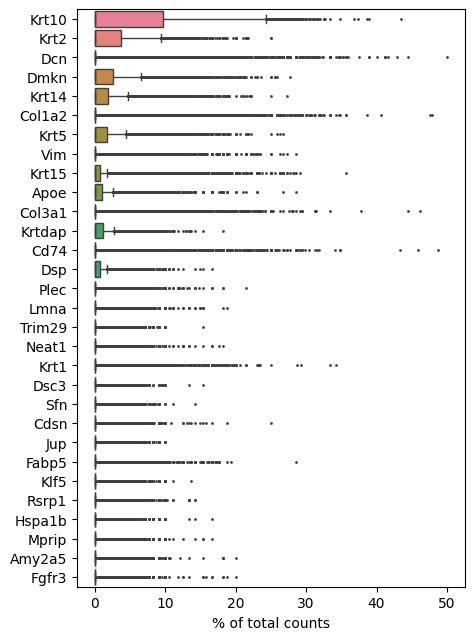

In [ ]:
#check for highly expressed genes - if deemed necessary you can exclude these from the computation of the normalisation factor for cells downstream. 
sc.pl.highest_expr_genes(master_anndata)

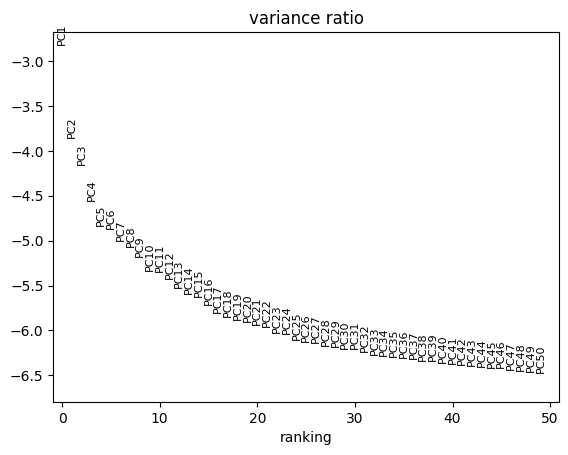

In [ ]:
#normalize cells, then carry out dimensionality reduction with p

#setting the random seed for reproducibility (do not use your personal info if making your GitHub public)
random_seed = 18
rng = np.random.default_rng(18)

master_anndata.layers["counts"] = master_anndata.X.copy()
sc.pp.normalize_total(master_anndata, inplace=True) #normalise each cell by total counts over all genes, so each cell has the same total count after normalisation
sc.pp.log1p(master_anndata)
sc.pl.pca_variance_ratio(master_anndata, n_pcs=50, log = True)

In [ ]:
#change depending on elbow plot values, where it starts plateauing
n_comps = 25

In [ ]:
#dimensionality reduction

sc.pp.pca(master_anndata, n_comps = n_comps) #required for downstream UMAP
sc.pp.neighbors(master_anndata) #also required for downstream UMAP
sc.tl.umap(master_anndata)
sc.tl.leiden(master_anndata, flavor = 'igraph')


In [102]:
master_anndata

AnnData object with n_obs × n_vars = 20127 × 5056
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'cell_labels', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_counts', 'n_genes', 'leiden'
    uns: 'log1p', 'pca', 'neighbors', 'umap', 'leiden'
    obsm: 'spatial', 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

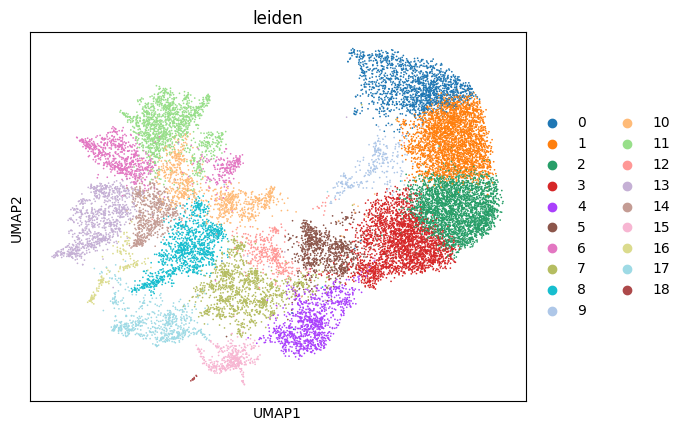

In [103]:
sc.pl.umap(
    master_anndata,
    color = ['leiden'] #####ADD IN PER-INDIVIDUAL COLOURING####

)